# M6: Final Model Comparison

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.models import load_model
from keras.backend import clear_session
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = '../data/processed'
SPLITS_DIR = '../data/splits'
SAVED_MODELS_DIR = '../saved_models'
BATCH_SIZE = 64


In [2]:
idx_test = np.load(os.path.join(SPLITS_DIR, 'idx_test.npy'))

y_match = np.load(os.path.join(PROCESSED_DIR, 'y_match.npy'))
y_sentiment = np.load(os.path.join(PROCESSED_DIR, 'y_sentiment.npy'))
y_fake = np.load(os.path.join(PROCESSED_DIR, 'y_fake.npy'))
y_trust = np.load(os.path.join(PROCESSED_DIR, 'y_trust.npy'))

y_match_test = y_match[idx_test]
y_sentiment_test = y_sentiment[idx_test]
y_fake_test = y_fake[idx_test]
y_trust_test = y_trust[idx_test]

# Data for text/features
X_text = np.load(os.path.join(PROCESSED_DIR, 'X_text.npy'), mmap_mode='r')
X_features = np.load(os.path.join(PROCESSED_DIR, 'X_features.npy'))

X_text_test = X_text[idx_test]
X_feat_test = X_features[idx_test]

# Data for image (Requires Generator)
X_img = np.load(os.path.join(PROCESSED_DIR, 'X_img.npy'), mmap_mode='r')
from keras.utils import Sequence
import math
class PredictGenerator(Sequence):
    def __init__(self, X, indices, batch_size):
        self.X = X
        self.indices = indices
        self.batch_size = batch_size
    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)
    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        return self.X[batch_idx].astype('float32')

img_test_gen = PredictGenerator(X_img, idx_test, BATCH_SIZE)


In [3]:
# Running memory-safe predictions

def get_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    return {
        "Model": name,
        "Accuracy": f"{acc*100:.1f}%",
        "F1-Macro": f"{f1*100:.1f}%",
        "Precision": f"{prec*100:.1f}%",
        "Recall": f"{rec*100:.1f}%"
    }

results = []

# M1
m1 = load_model(os.path.join(SAVED_MODELS_DIR, 'M1_best.keras'), compile=False)
pred1 = np.argmax(m1.predict(img_test_gen, verbose=0), axis=1)
results.append(get_metrics(y_match_test, pred1, "M1 (Image Match)"))
del m1; clear_session(); gc.collect()

# M2
m2 = load_model(os.path.join(SAVED_MODELS_DIR, 'M2_best.keras'), compile=False)
pred2 = np.argmax(m2.predict(X_text_test, verbose=0), axis=1)
results.append(get_metrics(y_sentiment_test, pred2, "M2 (Sentiment)"))
del m2; clear_session(); gc.collect()

# M3
m3 = load_model(os.path.join(SAVED_MODELS_DIR, 'M3_best.keras'), compile=False)
pred3 = np.argmax(m3.predict(X_text_test, verbose=0), axis=1)
results.append(get_metrics(y_fake_test, pred3, "M3 (Fake Review)"))
del m3; clear_session(); gc.collect()

# M4
m4 = load_model(os.path.join(SAVED_MODELS_DIR, 'M4_best.keras'), compile=False)
pred4 = np.argmax(m4.predict(X_feat_test, verbose=0), axis=1)
results.append(get_metrics(y_trust_test, pred4, "M4 (Tabular Trust)"))
del m4; clear_session(); gc.collect()


C:\Users\nourh\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


0

In [4]:
# Extracting features for M5
m1_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M1_extractor.keras'), compile=False)
feat1 = m1_ext.predict(img_test_gen, verbose=0)
del m1_ext; clear_session(); gc.collect()

m2_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M2_extractor.keras'), compile=False)
feat2 = m2_ext.predict(X_text_test, verbose=0)
del m2_ext; clear_session(); gc.collect()

m3_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M3_extractor.keras'), compile=False)
feat3 = m3_ext.predict(X_text_test, verbose=0)
del m3_ext; clear_session(); gc.collect()

m4_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M4_extractor.keras'), compile=False)
feat4 = m4_ext.predict(X_feat_test, verbose=0)
del m4_ext; clear_session(); gc.collect()

# Testing M5
m5 = load_model(os.path.join(SAVED_MODELS_DIR, 'M5_final.keras'), compile=False)
pred5 = np.argmax(m5.predict([feat1, feat2, feat3, feat4], verbose=0), axis=1)
results.append(get_metrics(y_trust_test, pred5, "M5 (Fusion Trust)"))
del m5; clear_session(); gc.collect()

df = pd.DataFrame(results)
print("\n", df.to_string(index=False))



              Model Accuracy F1-Macro Precision Recall
  M1 (Image Match)    86.6%    60.2%     64.4%  58.5%
    M2 (Sentiment)    85.7%    72.4%     69.6%  77.9%
  M3 (Fake Review)    98.9%    98.7%     98.8%  98.7%
M4 (Tabular Trust)    88.0%    74.2%     71.8%  89.4%
 M5 (Fusion Trust)    94.8%    89.7%     86.7%  94.3%


## Performance Visualization

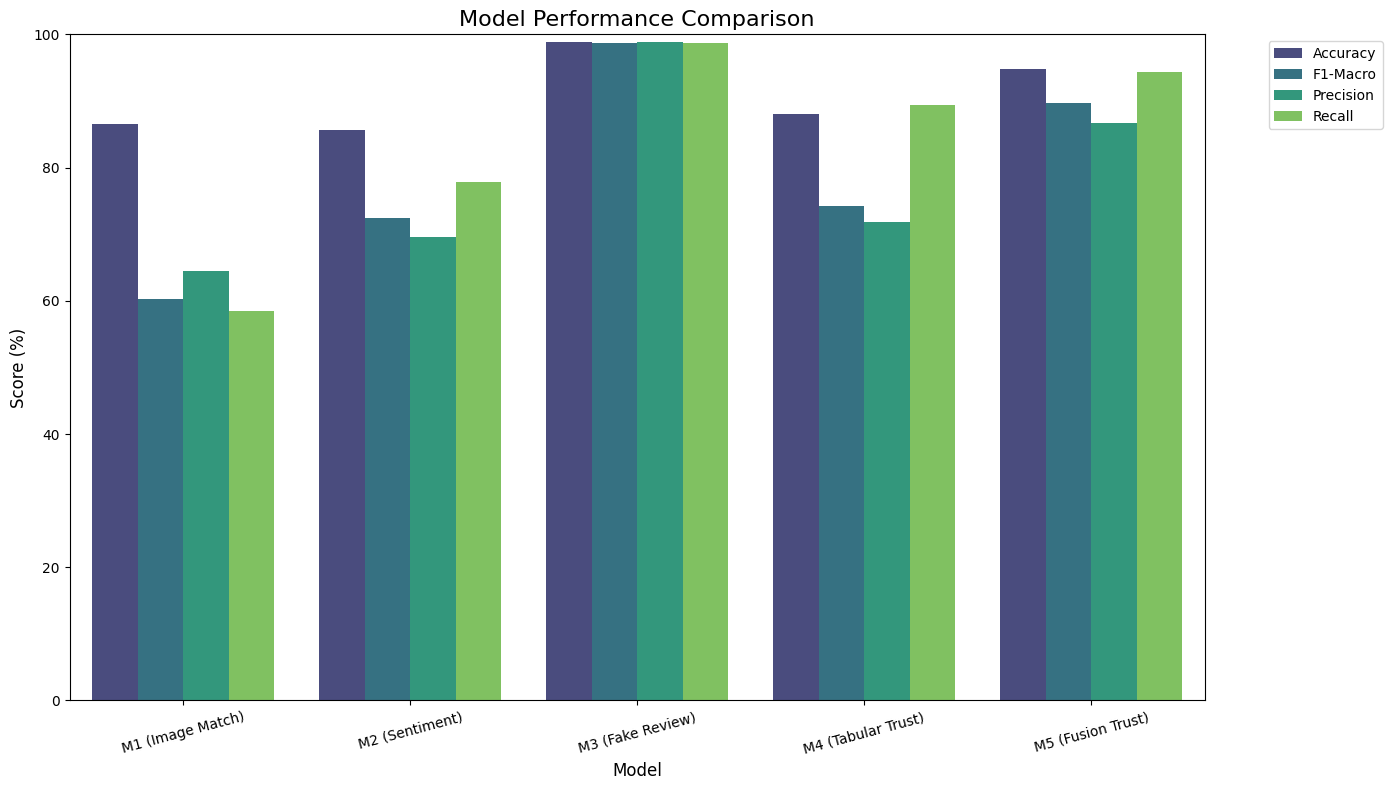

In [5]:
# Convert percentage strings back to floats for plotting
df_plot = df.copy()
for col in ['Accuracy', 'F1-Macro', 'Precision', 'Recall']:
    df_plot[col] = df_plot[col].str.rstrip('%').astype(float)

# Melt the dataframe for seaborn plotting
df_melted = df_plot.melt(id_vars='Model', var_name='Metric', value_name='Score (%)')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_melted, x='Model', y='Score (%)', hue='Metric', palette='viridis')
plt.title('Model Performance Comparison', fontsize=16)
plt.ylim(0, 100)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
